# Generación Datos Sintéticos con Drift

## 0. Configuración y Parametros

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

rng = np.random.default_rng(2270)

N_DAYS = 20
FREQ = "1min"
N_VARS = 10

PLANT_NAME = "synthetic_plant"
DATA_DIR = Path("synthetic_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)


GRADUAL_SHIFT_RANGE = (0.6, 1.2) # cuánto se mueve la media total en las rampas
ABRUPT_JUMP_RANGE   = (0.8, 2.0) # saltos bruscos
NOISE_SIGMA         = 0.3        # ruido base

# Parametro Serie de Tiempo AR(1)
AR1_PHI = 0.8

# Episodios y duraciones (ahora bien escalados a minutos)
EPISODES_MIN_MAX    = (2, 7) # Cantidad episodios
MIN_GAP_HOURS       = 6

GRADUAL_DUR_RANGE_H = (24, 24*5)     # Duración Drift Gradual
ABRUPT_STAB_RANGE_H = (6, 24)        # Duración Estable post Drift Abrupto

# Umbral mínimo de impacto para que valga la pena aplicar drift
IMPACT_MIN_SIGMAS   = 0.3


## 1. Generación de Series


In [15]:
# -------------------- Eje temporal y factor de conversión --------------------
dates = pd.date_range("2025-01-01", periods=N_DAYS*24*60, freq=FREQ, tz=None)
T = len(dates)
df = pd.DataFrame({"date_time": dates})

# cuántos pasos hay en una hora según FREQ
STEPS_PER_HOUR = int(pd.Timedelta("1H") / pd.Timedelta(FREQ))

MIN_GAP_STEPS = MIN_GAP_HOURS * STEPS_PER_HOUR
GRADUAL_DUR_RANGE_STEPS = (
    GRADUAL_DUR_RANGE_H[0] * STEPS_PER_HOUR,
    GRADUAL_DUR_RANGE_H[1] * STEPS_PER_HOUR,
)
ABRUPT_STAB_RANGE_STEPS = (
    ABRUPT_STAB_RANGE_H[0] * STEPS_PER_HOUR,
    ABRUPT_STAB_RANGE_H[1] * STEPS_PER_HOUR,
)

# -------------------- Helpers --------------------
def ar1_series(phi: float, sigma: float, size: int, rng=None):
    """Serie AR(1) con ruido N(0, sigma)."""
    if rng is None:
        rng = np.random.default_rng()
    x = np.zeros(size, dtype=float)
    x[0] = rng.normal(0.0, sigma)
    for t in range(1, size):
        x[t] = phi * x[t-1] + rng.normal(0.0, sigma)
    return x

def draw_non_overlapping_start(prev_end, max_start, min_gap_steps):
    """
    Devuelve un start_idx >= prev_end + min_gap_steps y < max_start.
    Si no hay espacio, retorna None.
    """
    earliest = prev_end + min_gap_steps if prev_end is not None else 0
    if earliest >= max_start:
        return None
    return int(rng.integers(low=earliest, high=max_start))

# -------------------- Generación por variable --------------------
for i in range(1, N_VARS+1):
    # baseline con inercia (AR1)
    base = ar1_series(AR1_PHI, NOISE_SIGMA, T, rng=rng)
    base_std = np.std(base) if np.std(base) > 1e-9 else 1.0

    # nº de episodios de drift en la variable
    n_episodes = int(rng.integers(EPISODES_MIN_MAX[0], EPISODES_MIN_MAX[1]))
    prev_end = None  # índice del fin del episodio anterior (en pasos)

    for _ in range(n_episodes):
        # Sesgo fuerte hacia drift gradual (80% gradual, 20% abrupto)
        drift_kind = "gradual" if rng.random() < 0.8 else "abrupt"

        if drift_kind == "gradual":
            # duración total de la rampa en pasos
            dur_steps = int(rng.integers(*GRADUAL_DUR_RANGE_STEPS))
            max_start = max(1, T - dur_steps - 1)
            start_idx = draw_non_overlapping_start(prev_end, max_start, MIN_GAP_STEPS)
            if start_idx is None:
                break
            end_idx = start_idx + dur_steps

            total_shift = float(rng.uniform(*GRADUAL_SHIFT_RANGE))
            impact = abs(total_shift) / max(base_std, 1e-9)
            if impact < IMPACT_MIN_SIGMAS:
                continue

            # mezcla de rampa lineal + S-shape para que sea bien progresivo
            lin = np.linspace(0.0, 1.0, end_idx - start_idx + 1)
            # "S" suave
            t_s = np.linspace(-3, 3, end_idx - start_idx + 1)
            s_shape = 1 / (1 + np.exp(-t_s))
            s_shape = (s_shape - s_shape.min()) / (s_shape.max() - s_shape.min())
            profile = 0.5 * lin + 0.5 * s_shape  # promedio de ambas
            ramp = profile * total_shift

            base[start_idx:end_idx+1] += ramp
            # Luego de la rampa, la serie queda en el nuevo nivel (no hace falta etiquetar)
            base[end_idx+1:] += total_shift

            prev_end = end_idx

        else:  # abrupto
            stab_steps = int(rng.integers(*ABRUPT_STAB_RANGE_STEPS))
            max_start = max(1, T - stab_steps - 1)
            start_idx = draw_non_overlapping_start(prev_end, max_start, MIN_GAP_STEPS)
            if start_idx is None:
                break
            end_idx = start_idx + stab_steps

            jump = float(rng.uniform(*ABRUPT_JUMP_RANGE))
            impact = abs(jump) / max(base_std, 1e-9)
            if impact < IMPACT_MIN_SIGMAS:
                continue

            # Salto inmediato y luego se estabiliza en el nuevo nivel
            base[start_idx:] += jump

            prev_end = end_idx

    df[f"var_{i}"] = base

In [16]:
PLANT_CSV = DATA_DIR / f"{PLANT_NAME}.csv"
df.to_csv(PLANT_CSV, index=False)
print(f"Synthetic data saved to {PLANT_CSV}")

Synthetic data saved to synthetic_data\synthetic_plant.csv


## 2. Visualización Series Generadas


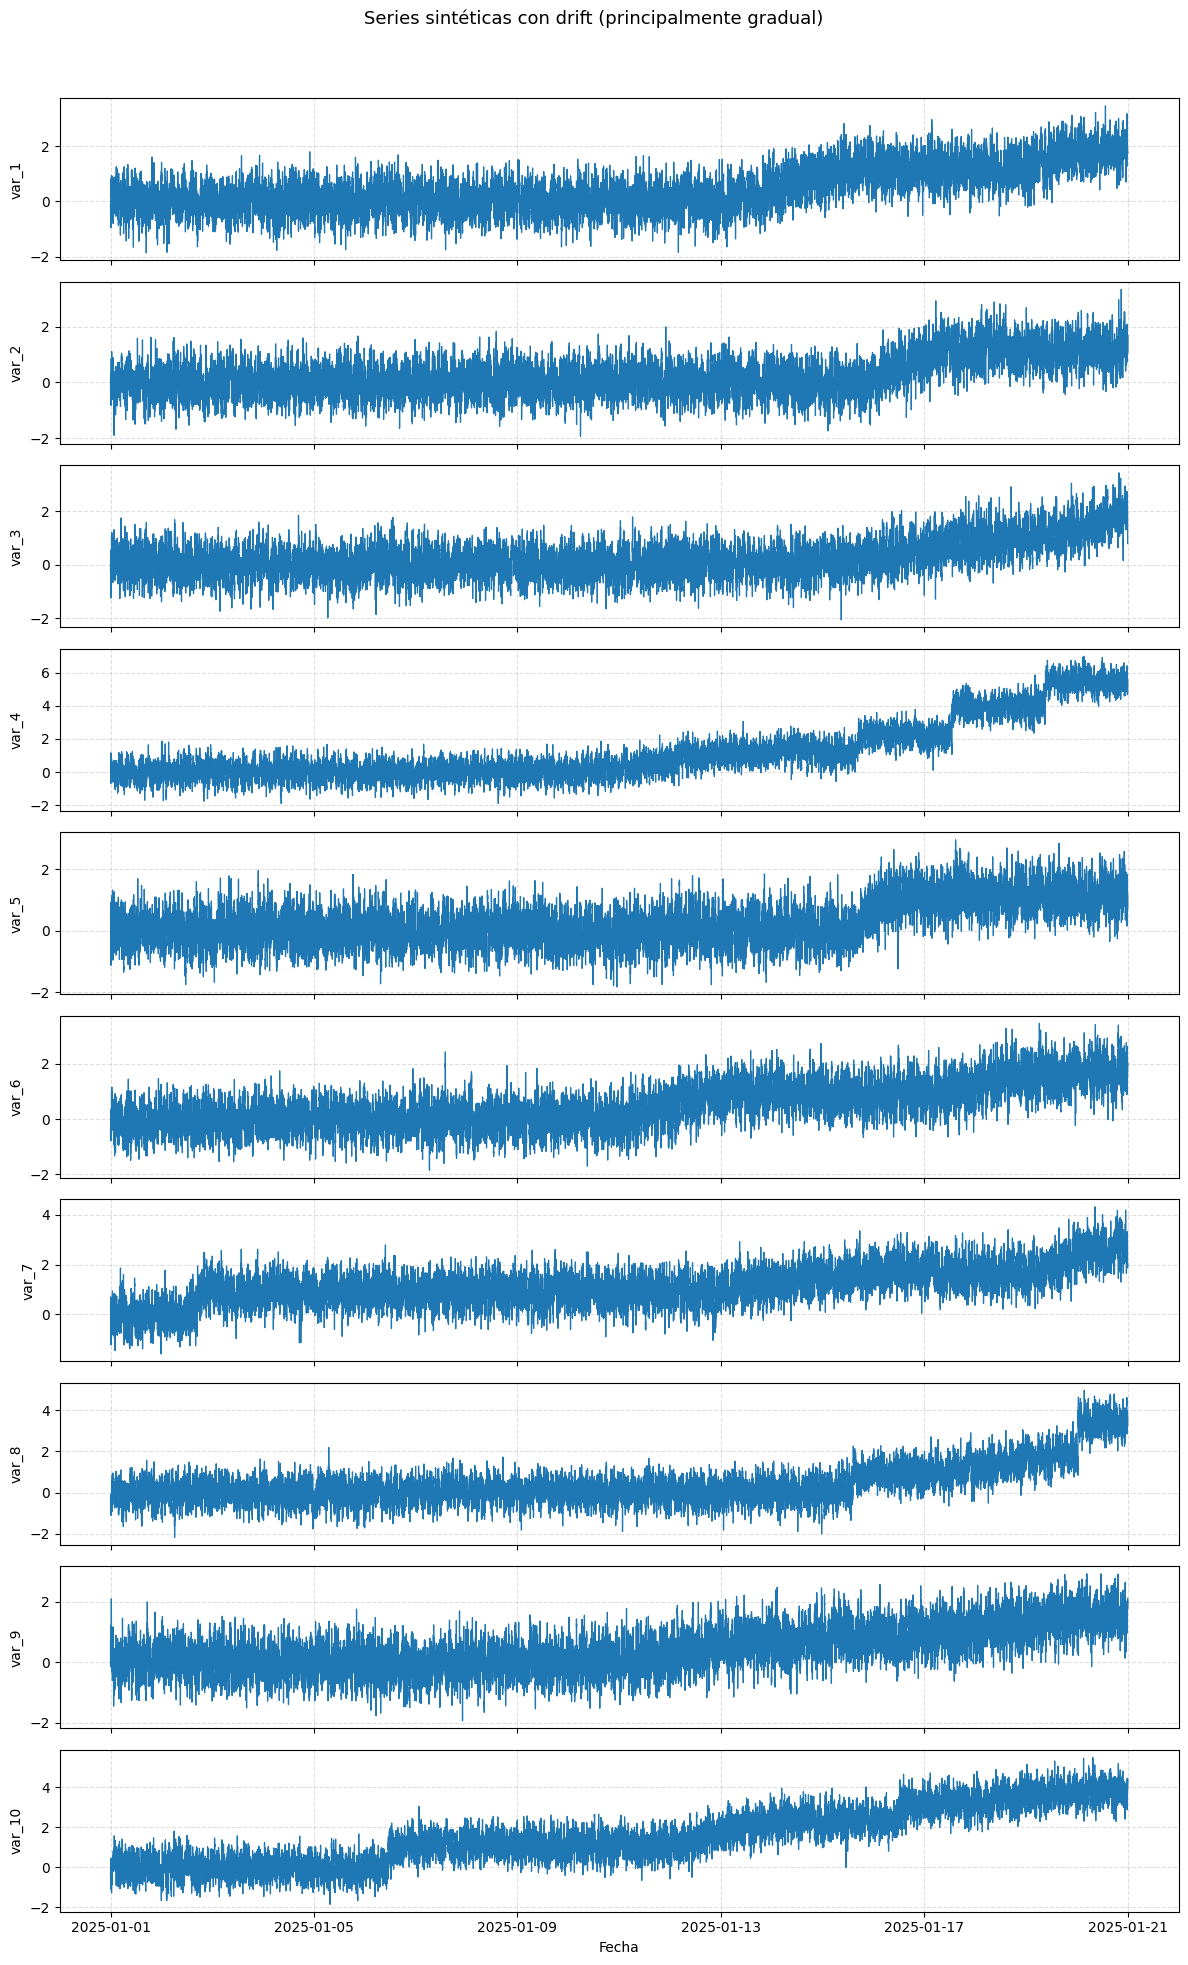

In [17]:
vars_to_plot = [f"var_{i}" for i in range(1, N_VARS+1)]
times = df["date_time"]

fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.0*len(vars_to_plot)), sharex=True)
for ax, v in zip(axes, vars_to_plot):
    ax.plot(times, df[v], lw=0.9, label=v)
    ax.set_ylabel(v)
    ax.grid(True, ls="--", alpha=0.4)

axes[-1].set_xlabel("Fecha")
fig.suptitle("Series sintéticas con drift (principalmente gradual)", fontsize=13)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()


# Etiquetado Datos Sintéticos

In [18]:
import plotly.graph_objects as go
import ipywidgets as W
from IPython.display import display
import re

EVENTS_CSV = DATA_DIR / f"{PLANT_NAME}_events.csv"


In [19]:
# ---------- Preparar df para etiquetar (usando el df ya generado) ----------
df_label = df.copy()  # df viene de la sección 1
df_label["date_time"] = pd.to_datetime(df_label["date_time"], errors="coerce")
df_label = df_label.dropna(subset=["date_time"]).set_index("date_time").sort_index()

# Nos quedamos solo con columnas numéricas (var_1, var_2, ...)
num_cols = [c for c in df_label.columns if pd.api.types.is_numeric_dtype(df_label[c])]
df_label = df_label[num_cols].copy()
assert df_label.shape[1] > 0, "No hay columnas numéricas para etiquetar."

current_col = df_label.columns[0]
episodes = []  # [{column, episode_start, episode_end}]

MIN_DURATION = pd.Timedelta(minutes=1)  # duración mínima permitida

# ---------- Figura base ----------
fig = go.FigureWidget()
fig.update_layout(
    title="Etiquetado manual de drift",
    xaxis=dict(title="Tiempo", rangeslider=dict(visible=True)),
    yaxis=dict(title="Valor"),
    uirevision=True,
)
fig.add_scatter(x=df_label.index, y=df_label[current_col], mode="lines", name=current_col)

# ---------- Utilidades ----------
def _normalize_hhmmss(s: str) -> str:
    """Normaliza 'H', 'H:M' o 'H:M:S' a 'HH:MM:SS' (con límites)."""
    s = (s or "").strip()
    if not s:
        return "00:00:00"
    m = re.match(r"^\s*(\d{1,2})(?::(\d{1,2}))?(?::(\d{1,2}))?\s*$", s)
    if not m:
        return "00:00:00"
    h = int(m.group(1) or 0)
    mi = int(m.group(2) or 0)
    se = int(m.group(3) or 0)
    h  = max(0, min(23, h))
    mi = max(0, min(59, mi))
    se = max(0, min(59, se))
    return f"{h:02d}:{mi:02d}:{se:02d}"

def refresh_plot():
    """Redibuja rectángulos de la columna actual."""
    with fig.batch_update():
        fig.layout.shapes = tuple([
            dict(
                type="rect",
                xref="x",
                yref="paper",
                x0=r["episode_start"],
                x1=r["episode_end"],
                y0=0,
                y1=1,
                fillcolor="rgba(200,60,60,0.25)",
                line=dict(color="rgba(200,60,60,0.9)"),
                layer="below",
            )
            for r in episodes if r["column"] == current_col
        ])

def _merge_intervals_per_var(eps_df: pd.DataFrame) -> pd.DataFrame:
    """Une solapes/duplicados por variable (intervalos limpios)."""
    if eps_df.empty:
        return eps_df
    eps_df = (
        eps_df.drop_duplicates()
              .dropna(subset=["column","episode_start","episode_end"])
              .copy()
    )
    eps_df["episode_start"] = pd.to_datetime(eps_df["episode_start"], errors="coerce")
    eps_df["episode_end"]   = pd.to_datetime(eps_df["episode_end"],   errors="coerce")
    eps_df = eps_df.dropna(subset=["episode_start","episode_end"])
    eps_df = eps_df[eps_df["episode_end"] > eps_df["episode_start"]]
    out = []
    for col, g in eps_df.groupby("column", sort=True):
        g = g.sort_values(["episode_start","episode_end"]).reset_index(drop=True)
        if g.empty:
            continue
        cur_s = g.loc[0, "episode_start"]
        cur_e = g.loc[0, "episode_end"]
        for _, r in g.iloc[1:].iterrows():
            s, e = r["episode_start"], r["episode_end"]
            if s <= cur_e:
                if e > cur_e:
                    cur_e = e
            else:
                out.append({"column": col, "episode_start": cur_s, "episode_end": cur_e})
                cur_s, cur_e = s, e
        out.append({"column": col, "episode_start": cur_s, "episode_end": cur_e})
    return pd.DataFrame(out, columns=["column","episode_start","episode_end"])

def _episodes_to_events(eps_df: pd.DataFrame) -> pd.DataFrame:
    """Intervalos -> Eventos (date_time,variable,event en {'start','end'})."""
    if eps_df.empty:
        return pd.DataFrame(columns=["date_time","variable","event"])
    rows = []
    for _, r in eps_df.iterrows():
        v = r["column"]
        t0 = pd.to_datetime(r["episode_start"])
        t1 = pd.to_datetime(r["episode_end"])
        rows.append({"date_time": t0, "variable": v, "event": "start"})
        rows.append({"date_time": t1, "variable": v, "event": "end"})
    ev = pd.DataFrame(rows)
    ev["date_time"] = pd.to_datetime(ev["date_time"])
    ev = ev.drop_duplicates(subset=["date_time","variable","event"])
    return ev.sort_values(["variable","date_time","event"]).reset_index(drop=True)

def _events_to_episodes(ev_df: pd.DataFrame) -> pd.DataFrame:
    """Eventos -> Intervalos (empareja start/end por variable)."""
    need = {"date_time","variable","event"}
    if ev_df.empty or not need.issubset(set(ev_df.columns)):
        return pd.DataFrame(columns=["column","episode_start","episode_end"])
    g = ev_df.copy()
    g["date_time"] = pd.to_datetime(g["date_time"], errors="coerce")
    g = g.dropna(subset=["date_time","variable","event"])
    g = g.sort_values(["variable","date_time","event"])
    rows = []
    for var, grp in g.groupby("variable", sort=True):
        open_t = None
        for _, r in grp.iterrows():
            ev = str(r["event"]).lower()
            if ev == "start":
                open_t = r["date_time"]
            elif ev == "end" and open_t is not None and r["date_time"] > open_t:
                rows.append({
                    "column": var,
                    "episode_start": open_t,
                    "episode_end": r["date_time"],
                })
                open_t = None
    eps = pd.DataFrame(rows)
    return _merge_intervals_per_var(eps) if not eps.empty else eps

def _get_dt(date_widget, hour_widget):
    hh = _normalize_hhmmss(hour_widget.value)
    return pd.to_datetime(f"{date_widget.value} {hh}")

def _set_pickers(t0, t1):
    t0 = pd.to_datetime(t0)
    t1 = pd.to_datetime(t1)
    date_ini.value = t0.date()
    hour_ini.value = _normalize_hhmmss(t0.strftime("%H:%M:%S"))
    date_fin.value = t1.date()
    hour_fin.value = _normalize_hhmmss(t1.strftime("%H:%M:%S"))
    with out_msg:
        print(f"Prefill: {t0} → {t1}")

def _interval_overlaps(col, t0, t1):
    """True si [t0,t1] se solapa con algún episodio existente de la misma variable."""
    for r in episodes:
        if r["column"] != col:
            continue
        a0, a1 = r["episode_start"], r["episode_end"]
        # solape estricto (permitimos que se toquen solo en el borde)
        if max(t0, a0) < min(t1, a1):
            return True
    return False

def _save_events_to_csv():
    eps_df = pd.DataFrame(episodes)
    eps_merged = _merge_intervals_per_var(eps_df) if not eps_df.empty else eps_df
    events_df = _episodes_to_events(eps_merged)
    EVENTS_CSV.parent.mkdir(parents=True, exist_ok=True)
    events_df.to_csv(EVENTS_CSV, index=False)
    with out_msg:
        print(f"💾 CSV actualizado: {EVENTS_CSV} ({len(events_df)} filas)")
        if not events_df.empty:
            print(events_df.head())

# ---------- Widgets ----------
col_dd = W.Dropdown(
    options=list(df_label.columns),
    value=current_col,
    description="Serie:",
    layout=W.Layout(width="360px"),
)

date_ini = W.DatePicker(description="Inicio:")
hour_ini = W.Text(value="00:00:00", description="Hora:")
date_fin = W.DatePicker(description="Fin:")
hour_fin = W.Text(value="00:00:00", description="Hora:")

btn_add   = W.Button(description="Agregar intervalo", button_style="info")
btn_load  = W.Button(description="Cargar CSV", tooltip="Reconstruye intervalos desde el CSV de eventos")
btn_clear = W.Button(description="Borrar de columna", button_style="warning", tooltip="Borra episodios visibles de la serie actual")

out_msg = W.Output(
    layout=W.Layout(max_height="170px", overflow="auto", border="1px solid #444", padding="4px")
)

# ---------- Callbacks núcleo ----------
def set_series(col):
    global current_col
    current_col = col
    with fig.batch_update():
        fig.data = ()
        fig.add_scatter(x=df_label.index, y=df_label[col], mode="lines", name=col)
    refresh_plot()

def on_change_col(change):
    if change["name"] != "value":
        return
    set_series(change["new"])
    _set_pickers(df_label.index.min(), df_label.index.min() + pd.Timedelta(hours=1))

def on_add(_):
    if not date_ini.value or not date_fin.value:
        with out_msg:
            print("⚠️ Debes elegir fechas de inicio y fin.")
        return
    t0 = _get_dt(date_ini, hour_ini)
    t1 = _get_dt(date_fin, hour_fin)

    # Evitar intervalos vacíos o demasiado cortos
    if t1 <= t0:
        with out_msg:
            print("⚠️ El fin debe ser posterior al inicio.")
        return
    if (t1 - t0) < MIN_DURATION:
        with out_msg:
            print(f"⚠️ La duración mínima es de {MIN_DURATION}. Intervalo no agregado.")
        return

    # Evitar solapes con episodios existentes de la misma serie
    if _interval_overlaps(current_col, t0, t1):
        with out_msg:
            print(f"⚠️ El intervalo {t0} → {t1} se solapa con otra etiqueta de {current_col}. No se agrega.")
        return

    episodes.append({"column": current_col, "episode_start": t0, "episode_end": t1})
    refresh_plot()
    _save_events_to_csv()
    with out_msg:
        print(f"➕ Episodio agregado ({current_col}): {t0} → {t1}")

def on_load(_):
    global episodes
    if EVENTS_CSV.exists():
        try:
            ev = pd.read_csv(EVENTS_CSV)
            eps = _events_to_episodes(ev)
            episodes = eps.to_dict(orient="records")
            refresh_plot()
            with out_msg:
                print(f"📥 Cargados {len(episodes)} episodios reconstruidos desde {EVENTS_CSV}")
        except Exception as e:
            with out_msg:
                print(f"⚠️ Error al cargar eventos: {e}")
    else:
        with out_msg:
            print(f"⚠️ No existe {EVENTS_CSV}. Guarda primero desde la UI o crea el archivo.")

def on_clear(_):
    global episodes
    before = len(episodes)
    episodes = [r for r in episodes if r["column"] != current_col]
    removed = before - len(episodes)
    refresh_plot()
    _save_events_to_csv()
    with out_msg:
        print(f"🧹 Eliminados {removed} episodios de {current_col}")

# ---------- Wiring + UI ----------
col_dd.observe(on_change_col, names="value")
btn_add.on_click(on_add)
btn_load.on_click(on_load)
btn_clear.on_click(on_clear)

set_series(current_col)
_set_pickers(df_label.index.min(), df_label.index.min() + pd.Timedelta(hours=1))

row_top     = W.HBox([col_dd, btn_load, btn_clear])
row_pickers = W.HBox([date_ini, hour_ini, date_fin, hour_fin, btn_add])

ui = W.VBox([row_top, row_pickers, out_msg])
display(ui, fig)

print(f"➡️ El CSV de eventos se mantiene actualizado en: {EVENTS_CSV.as_posix()}")

FigureWidget({
    'data': [{'mode': 'lines',
              'name': 'var_1',
              'type': 'scatter',
              'uid': '5c51c902-e041-4a7d-8911-9c9479098cf2',
              'x': array([datetime.datetime(2025, 1, 1, 0, 0),
                          datetime.datetime(2025, 1, 1, 0, 1),
                          datetime.datetime(2025, 1, 1, 0, 2), ...,
                          datetime.datetime(2025, 1, 20, 23, 57),
                          datetime.datetime(2025, 1, 20, 23, 58),
                          datetime.datetime(2025, 1, 20, 23, 59)], dtype=object),
              'y': array([-0.11619544, -0.74487262, -0.80024123, ...,  1.83994616,  1.73244954,
                           1.77382676])}],
    'layout': {'template': '...',
               'title': {'text': 'Etiquetado manual de drift'},
               'uirevision': True,
               'xaxis': {'rangeslider': {'visible': True}, 'title': {'text': 'Tiempo'}},
               'yaxis': {'title': {'text': 'Valor'}}}
})

➡️ El CSV de eventos se mantiene actualizado en: synthetic_data/synthetic_plant_events.csv
